# 1: Carregamento e unificação

In [2]:
# Carregar os data frames e bibliotecas:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregando os datasets
df_flights = pd.read_csv('flights.csv', low_memory=False)
df_airports = pd.read_csv('airports.csv')
df_airlines = pd.read_csv('airlines.csv')

# 2. Primeira inspeção
print(f"Voos: {df_flights.shape}")
print(f"Colunas de voos: {df_flights.columns.tolist()}")

Voos: (5819079, 31)
Colunas de voos: ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']


In [3]:
# 2. Unir voos com companhias aéreas para ter o nome completo da empresa
df_completo = df_flights.merge(df_airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
# Remover a coluna duplicada do código
df_completo = df_completo.drop(columns=['IATA_CODE'])
# Renomear a coluna AIRLINE_y para facilitar (AIRLINE_x é o código, AIRLINE_y é o nome)
df_completo = df_completo.rename(columns={'AIRLINE_x': 'AIRLINE_CODE', 'AIRLINE_y': 'AIRLINE_NAME'})

In [4]:
# 3. Unir com aeroportos (Origem)
df_completo = df_completo.merge(df_airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE']], 
                                left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')
df_completo = df_completo.rename(columns={'AIRPORT': 'ORIGIN_AIRPORT_NAME', 'CITY': 'ORIGIN_CITY', 'STATE': 'ORIGIN_STATE'}).drop(columns=['IATA_CODE'])

print(f"Dataset carregado com {df_completo.shape[0]} linhas e {df_completo.shape[1]} colunas.")

Dataset carregado com 5819079 linhas e 35 colunas.


In [5]:
df_completo.head()


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_CODE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,NaN,NaN,NaN,NaN,NaN,NaN,US Airways Inc.,San Francisco International Airport,San Francisco,CA
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA


# 2: Limpeza de Dados e Tratamento de Nulos

In [6]:
# 1. Filtrar voos cancelados ou desviados para análise de atrasos
# Se o voo foi cancelado, ele não "atrasou" no sentido de tempo de voo, ele não ocorreu.
df_analise = df_completo[(df_completo['CANCELLED'] == 0) & (df_completo['DIVERTED'] == 0)].copy()

In [7]:
# 2. Tratamento de nulos nas colunas de motivo de atraso
# Na base do DOT EUA, se o voo não atrasou mais de 15 min, os motivos ficam vazios (NaN).
# O correto é preencher com 0.
cols_motivos = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
df_analise[cols_motivos] = df_analise[cols_motivos].fillna(0)

In [8]:
# 3. Criar a variável alvo (Target) para o modelo supervisionado futuro
# Convencionalmente, > 15 minutos de atraso na chegada (ARRIVAL_DELAY) é considerado "Atrasado"
df_analise['IS_DELAYED'] = (df_analise['ARRIVAL_DELAY'] > 15).astype(int)

print("Nulos restantes nas colunas principais:\n", df_analise[['ARRIVAL_DELAY', 'DEPARTURE_DELAY']].isnull().sum())

Nulos restantes nas colunas principais:
 ARRIVAL_DELAY      0
DEPARTURE_DELAY    0
dtype: int64


# 3: Primeiro Insight Visual (Estatística Descritiva)

C:\Users\hcapristano\AppData\Local\Temp\ipykernel_36480\1922190028.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=atraso_por_cia.values, y=atraso_por_cia.index, palette='magma')


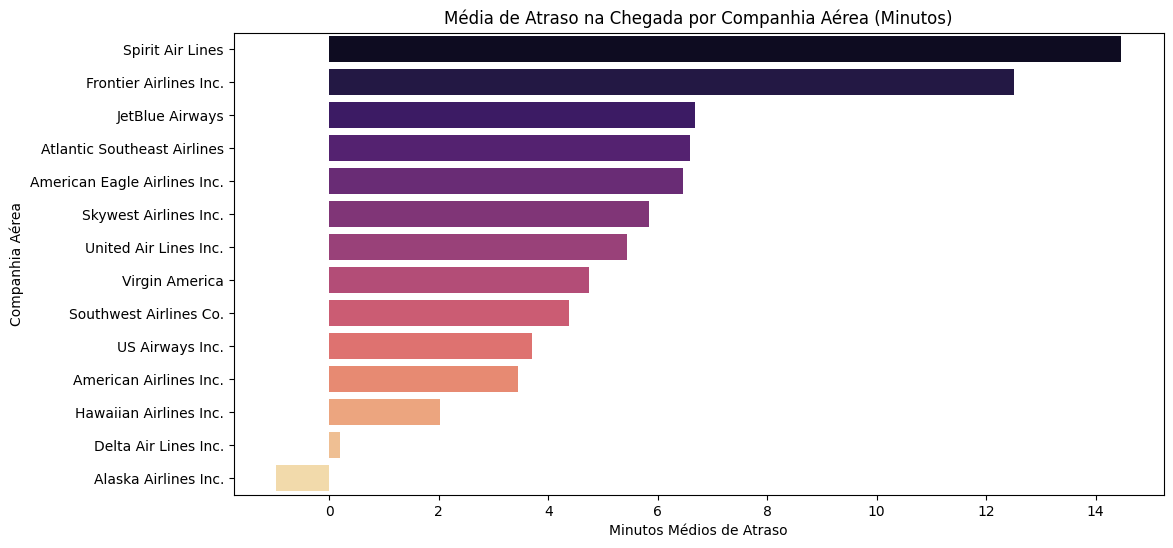

In [9]:
plt.figure(figsize=(12, 6))
# Calculando a média de atraso por companhia
atraso_por_cia = df_analise.groupby('AIRLINE_NAME')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)

sns.barplot(x=atraso_por_cia.values, y=atraso_por_cia.index, palette='magma')
plt.title('Média de Atraso na Chegada por Companhia Aérea (Minutos)')
plt.xlabel('Minutos Médios de Atraso')
plt.ylabel('Companhia Aérea')
plt.show()

# 4: Engenharia de Atributos (Tempo e Período)

In [10]:
# 1. Função para categorizar o período do dia baseado na hora agendada
def categorizar_periodo(hora_inteira):
    # Extrai a hora (os primeiros dígitos antes dos minutos)
    hora = hora_inteira // 100
    if 5 <= hora < 12:
        return 'Manhã'
    elif 12 <= hora < 18:
        return 'Tarde'
    elif 18 <= hora < 24:
        return 'Noite'
    else:
        return 'Madrugada'

In [11]:
# 2. Aplicar a função
df_analise['PERIODO_DIA'] = df_analise['SCHEDULED_DEPARTURE'].apply(categorizar_periodo)

In [14]:
# 3. Mapear o dia da semana para nomes (opcional, mas ajuda na leitura do gráfico)
dias_map = {1: 'Seg', 2: 'Ter', 3: 'Qua', 4: 'Qui', 5: 'Sex', 6: 'Sáb', 7: 'Dom'}
df_analise['NOME_DIA_SEMANA'] = df_analise['DAY_OF_WEEK'].map(dias_map)
print("Novas colunas criadas com sucesso!")

Novas colunas criadas com sucesso!


In [15]:
df_analise.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_CODE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,IS_DELAYED,PERIODO_DIA,NOME_DIA_SEMANA
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,0.0,0.0,0.0,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,0,Madrugada,Qui
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,0,Madrugada,Qui
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,0.0,0.0,0.0,US Airways Inc.,San Francisco International Airport,San Francisco,CA,0,Madrugada,Qui
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,0,Madrugada,Qui
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,0.0,0.0,0.0,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,0,Madrugada,Qui


# 5: Insights de Sazonalidade e Horário

C:\Users\hcapristano\AppData\Local\Temp\ipykernel_36480\3761421586.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PERIODO_DIA', y='ARRIVAL_DELAY', data=df_analise,


Text(0, 0.5, 'Minutos de Atraso')

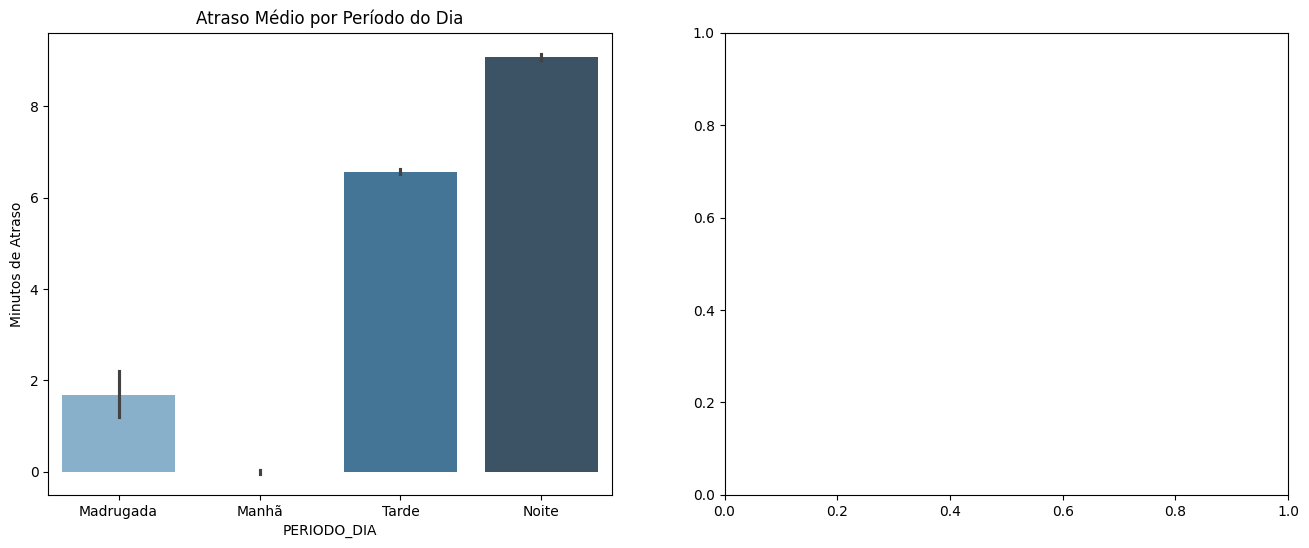

In [16]:
# Criar uma figura com dois subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Atraso Médio por Período do Dia
sns.barplot(x='PERIODO_DIA', y='ARRIVAL_DELAY', data=df_analise, 
            order=['Madrugada', 'Manhã', 'Tarde', 'Noite'], ax=ax[0], palette='Blues_d')
ax[0].set_title('Atraso Médio por Período do Dia')
ax[0].set_ylabel('Minutos de Atraso')

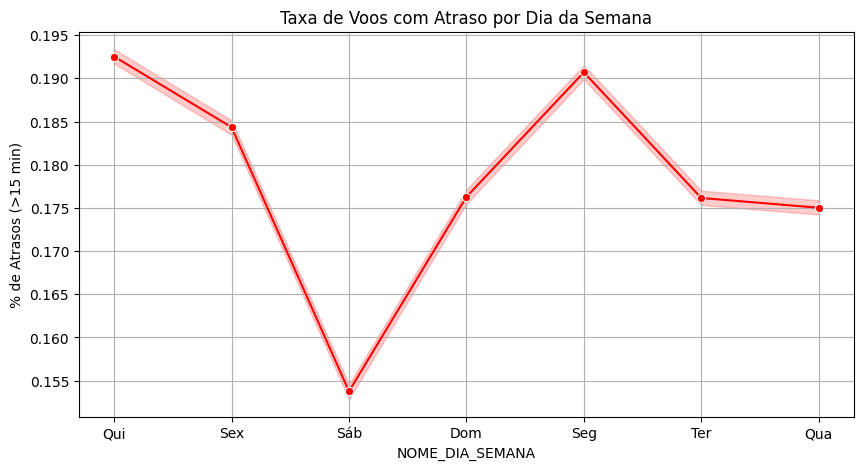

In [18]:
# Gráfico 2: Probabilidade de Atraso (>15min) por Dia da Semana
plt.figure(figsize=(10, 5))
sns.lineplot(x='NOME_DIA_SEMANA', y='IS_DELAYED', data=df_analise, marker='o', sort=False, color='red')
plt.title('Taxa de Voos com Atraso por Dia da Semana')
plt.ylabel('% de Atrasos (>15 min)')
plt.grid(True)
plt.show()

In [ ]:
# Gerar o arquivo .pkl:
df_analise.to_pickle('dados_voos_limpos.pkl')
print("Arquivo 'dados_voos_limpos.pkl' gerado com sucesso!")

Arquivo 'dados_voos_limpos.pkl' gerado com sucesso!
